# Notebook 04 — Matching policy and sensitivity analysis

**Purpose.** This notebook documents the object-level matching framework used
to generate the benchmark metrics, compares the canonical **OR** policy with
the stricter **AND** policy, and evaluates whether the model rankings are
robust to reasonable variation in the matching thresholds.

**Audience.** This notebook is intended for reviewers and collaborators who
want to inspect the evaluation rule itself: how predicted objects are paired
with ground-truth ecDNA objects, why the canonical operating point was chosen,
and whether the conclusions depend strongly on a single threshold setting.

## Matching framework

Each prediction mask and ground-truth mask is converted into candidate objects
using 8-connected components with a minimum component area of 3 pixels. For
each predicted object $i$ and ground-truth object $j$, the evaluation computes
a combined assignment cost:

$$
C_{ij}
=
\alpha \left(1 - \mathrm{IoU}_{ij}\right)
+
(1 - \alpha)\frac{d_{ij}}{d_{\mathrm{max}}}
$$

where $d_{ij}$ is centroid distance, $d_{\mathrm{max}}$ is the distance
tolerance, and $\alpha = 0.5$ gives equal weight to overlap and distance.
Candidate pairs are filtered by one of two matching policies:

- **OR policy:** valid if $d_{ij} \le d_{\mathrm{max}}$ **or**
  $\mathrm{IoU}_{ij} \ge \mathrm{IoU}_{\mathrm{min}}$
- **AND policy:** valid if $d_{ij} \le d_{\mathrm{max}}$ **and**
  $\mathrm{IoU}_{ij} \ge \mathrm{IoU}_{\mathrm{min}}$

Invalid pairs are assigned a large cost and excluded from the Hungarian
assignment. Assigned prediction–GT pairs are counted as true positives.
Unmatched ground-truth objects are counted as false negatives. Predictions with
no valid candidate are counted as false positives. Redundant predictions that
had at least one valid candidate but lost the global assignment are placed in an
**ignored** bucket rather than counted as false positives.

## Canonical operating point

The main benchmark uses the following frozen matching configuration:

$$
d_{\mathrm{max}} = 20\ \mathrm{px}, \quad
\mathrm{IoU}_{\mathrm{min}} = 0.1, \quad
\alpha = 0.5, \quad
\mathrm{policy} = \mathrm{OR}
$$

This notebook uses the frozen benchmark summaries and sensitivity-sweep CSVs
generated by the evaluation pipeline. It does not rerun the full benchmark
inside the notebook.

## Outputs

All files are written to `release/figures/notebook04/`.

| File | Description |
|------|-------------|
| `fig2_matching_example.svg` | Lightweight worked example illustrating object matching |
| `figS_or_vs_and_headline.svg` | Headline object-level F1 under OR versus AND matching |
| `figS_sensitivity_heatmaps.svg` | Sensitivity heatmaps over $d_{\mathrm{max}}$ and $\mathrm{IoU}_{\mathrm{min}}$ |
| `figS_sensitivity_range.svg` | Robustness range of object-level F1 across the sensitivity grid |
| `notebook04_output_manifest.csv` | Manifest of generated figures and source-data files |nifest.csv` | Manifest of generated figures and source-data files |st.csv` | Manifest of generated figures and source-data files |

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

import cv2
from IPython.display import display

# ── Repository root and import path ─────────────────────────────────────────
# The project uses a src-layout, so notebooks should add REPO_ROOT/src to the
# Python path. This mirrors editable installation and keeps local imports stable
# across login nodes, compute nodes, and notebook sessions.

REPO_ROOT = Path(os.getcwd()).resolve()

if not (REPO_ROOT / 'pyproject.toml').exists():
    candidate = REPO_ROOT.parent
    if (candidate / 'pyproject.toml').exists():
        REPO_ROOT = candidate

if not (REPO_ROOT / 'pyproject.toml').exists():
    raise FileNotFoundError(
        'Could not locate repository root containing pyproject.toml. '
        f'Current working directory: {Path(os.getcwd()).resolve()}'
    )

SRC_DIR = REPO_ROOT / 'src'
IMPORT_DIR = SRC_DIR if SRC_DIR.exists() else REPO_ROOT

if str(IMPORT_DIR) not in sys.path:
    sys.path.insert(0, str(IMPORT_DIR))

print(f'Repo root: {REPO_ROOT}')
print(f'Python import path: {IMPORT_DIR}')

# ── Data paths ──────────────────────────────────────────────────────────────
DATA_ROOT = Path('/work/users/b/e/behnamie/ecDNA_Data/bioimage_archive')

RGB_DIR = DATA_ROOT / 'rgb'
GT_DIR = DATA_ROOT / 'gt_image'
ROI_DIR = DATA_ROOT / 'roi_mask'
FULL_META_CSV = DATA_ROOT / 'metadata_internal.csv'

# Frozen benchmark outputs.
FROZEN_ROOT = REPO_ROOT / 'release' / 'frozen_results'
FROZEN_OR = FROZEN_ROOT / 'or_matching'
FROZEN_AND = FROZEN_ROOT / 'and_matching'

SENS_DIR = FROZEN_ROOT / 'sensitivity'
SENS_CSV = SENS_DIR / 'sensitivity_sweep.csv'

# Prediction directory used only for the lightweight worked example.
ECCOUNT_THR_DIR = Path(
    '/work/users/b/e/behnamie/ecDNA_Data/benchmark/predictions/eccount_threshold'
)

# Output directory.
OUT_DIR = REPO_ROOT / 'release' / 'figures' / 'notebook04'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Figure output directory: {OUT_DIR}')

# ── Anchor image for the worked example ─────────────────────────────────────
ANCHOR_UID = 'ncih2170_facs_fish_0723_low_her2_52'
ANCHOR_INSET_BBOX = [1247, 1225, 1458, 1353]  # x0, y0, x1, y1, full-resolution pixels

# ── Model order and palettes ────────────────────────────────────────────────
# Notebook 04 can handle the full seven-model sensitivity sweep. If one of the
# frozen CSVs contains only the six paper-facing models, downstream cells will
# automatically retain the models present in that file.

MODEL_COLORS = {
    'Classic (before opt)':      '#A0A0A0',
    'Classic (after opt)':       '#54A24B',
    'Label Engine':              '#E45756',
    'ecSeg':                     '#B279A2',
    'MIA':                       '#4C78A8',
    'ecCount (threshold mask)':  '#9C755F',
    'ecCount (peaks)':           '#F58518',
}

MODEL_ORDER = list(MODEL_COLORS.keys())

# Aliases used to normalize model labels across old and new frozen CSVs.
MODEL_ALIASES = {
    'classical_before_opt':      'Classic (before opt)',
    'classic_before_opt':        'Classic (before opt)',
    'Classic before opt':        'Classic (before opt)',
    'Classic (before opt)':      'Classic (before opt)',

    'classical':                 'Classic (after opt)',
    'classical_after_opt':       'Classic (after opt)',
    'classic_after_opt':         'Classic (after opt)',
    'Classic after opt':         'Classic (after opt)',
    'Classic (after opt)':       'Classic (after opt)',

    'label_engine':              'Label Engine',
    'Label Engine':              'Label Engine',

    'ecseg':                     'ecSeg',
    'ecSeg':                     'ecSeg',

    'mia':                       'MIA',
    'MIA':                       'MIA',

    'eccount_threshold':         'ecCount (threshold mask)',
    'ecCount threshold':         'ecCount (threshold mask)',
    'ecCount (threshold mask)':  'ecCount (threshold mask)',

    'eccount_peaks':             'ecCount (peaks)',
    'ecCount peaks':             'ecCount (peaks)',
    'ecCount (peaks)':           'ecCount (peaks)',
}

POLICY_COLORS = {
    'OR':  '#4C78A8',
    'AND': '#E45756',
}

# Canonical sensitivity grid. These values match the frozen sensitivity sweep.
D_MAX_GRID = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100]
IOU_GRID = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
POLICIES = ['OR', 'AND']

CANONICAL_D_MAX = 20
CANONICAL_IOU_MIN = 0.1
CANONICAL_ALPHA = 0.5
CANONICAL_POLICY = 'OR'
MIN_COMPONENT_AREA = 3

# ── Publication style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6.2,
    'ytick.labelsize':   6.2,
    'legend.fontsize':   6.2,
    'figure.titlesize':  8,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
    'savefig.dpi':       300,
    'svg.fonttype':      'none',
    'pdf.fonttype':      42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

def save_fig(fig, name):
    """Save a figure as SVG and PNG in the notebook output directory."""
    svg = OUT_DIR / f'{name}.svg'
    png = OUT_DIR / f'{name}.png'

    fig.savefig(svg, format='svg', bbox_inches='tight')
    fig.savefig(png, format='png', dpi=150, bbox_inches='tight')

    print(f'Saved: {svg.name}')
    print(f'Saved: {png.name}')


def canonical_cell_line(x):
    """Standardise cell-line labels for display and grouping."""
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper().replace('-', '').replace('_', '').replace(' ', '')

    return {
        'NCIH2170':  'NCI-H2170',
        'SUM159PT':  'SUM159PT',
        'SNU16':     'SNU16',
        'COLO320DM': 'COLO320DM',
        'NCIH716':   'NCI-H716',
    }.get(s, str(x).strip())


def canonical_model_name(x):
    """Standardise model labels across frozen CSV revisions."""
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()

    if raw in MODEL_ALIASES:
        return MODEL_ALIASES[raw]

    key = raw.strip().lower().replace('-', '_').replace(' ', '_')
    key = key.replace('(', '').replace(')', '')

    return MODEL_ALIASES.get(key, raw)


def ordered_models_present(df, model_col='model'):
    """Return canonical model order restricted to models present in a dataframe."""
    present = set(df[model_col].dropna().astype(str))
    ordered = [m for m in MODEL_ORDER if m in present]
    extras = sorted(present - set(MODEL_ORDER))
    return ordered + extras


def color_for_model(model_name):
    """Return a stable color for known models and a neutral fallback otherwise."""
    return MODEL_COLORS.get(str(model_name), '#333333')


def find_metric_column(df, candidates, label):
    """Return the first matching metric column from a list of aliases."""
    for c in candidates:
        if c in df.columns:
            return c

    raise KeyError(
        f'Could not find {label}. Tried {candidates}. '
        f'Available columns: {list(df.columns)}'
    )


def robust_rgb_display(rgb):
    """Contrast-stretch an RGB crop for visualization only."""
    arr = rgb.astype(np.float32)
    out = np.zeros_like(arr, dtype=np.float32)

    for c in range(3):
        lo, hi = np.percentile(arr[..., c], [1, 99.5])
        if hi > lo:
            out[..., c] = np.clip((arr[..., c] - lo) / (hi - lo), 0, 1)
        else:
            out[..., c] = arr[..., c] / 255.0

    return np.clip(out, 0, 1)


print('Setup complete.')
print(f'Model order ({len(MODEL_ORDER)} models):')
for model_name in MODEL_ORDER:
    print(f'  - {model_name}')

Repo root: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench
Python import path: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/src
Figure output directory: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04
Setup complete.
Model order (7 models):
  - Classic (before opt)
  - Classic (after opt)
  - Label Engine
  - ecSeg
  - MIA
  - ecCount (threshold mask)
  - ecCount (peaks)


## §1 — Lightweight worked example on the anchor image

We begin with a single-image example to make the matching rule concrete. The
example uses the same anchor image as Notebook 03 and the ecCount threshold
prediction. We load the RGB image, ground-truth mask, and prediction mask, then
extract connected-component objects from the two binary masks.

This section is intentionally lightweight. It prepares one image for visual
explanation of the matching policy, while the full OR/AND benchmark comparison
and multi-model sensitivity analysis are read from frozen CSVs in later
sections. sections.

In [2]:
# ── §1: Load anchor image, GT mask, and one prediction mask ─────────────────
# Worked example input:
#   - RGB anchor image
#   - GT binary mask
#   - ecCount threshold prediction mask
#
# The full benchmark is not recomputed in this notebook. This cell only prepares
# one anchor image for the worked matching example.

from ecdna_bench.evaluation.objects import objects_from_mask

if not FULL_META_CSV.exists():
    raise FileNotFoundError(f'Metadata CSV not found: {FULL_META_CSV}')

full_meta = pd.read_csv(FULL_META_CSV)

if 'unique_id' not in full_meta.columns:
    raise KeyError(
        f'Metadata file does not contain unique_id column. '
        f'Available columns: {list(full_meta.columns)}'
    )

anchor_matches = full_meta[full_meta['unique_id'] == ANCHOR_UID]

if anchor_matches.empty:
    raise ValueError(f'Anchor UID not found in metadata: {ANCHOR_UID}')

anchor_row = anchor_matches.iloc[0]


def find_image(base_dir, uid, row, col_name):
    """Find one image by metadata filename first, then UID glob fallback."""
    base_dir = Path(base_dir)

    if col_name in row.index and pd.notna(row[col_name]):
        p = base_dir / str(row[col_name])
        if p.exists():
            return p

    for ext in ['.png', '.tif', '.tiff']:
        candidates = sorted(base_dir.rglob(f'{uid}{ext}'))
        if candidates:
            return candidates[0]

    return None


anchor_rgb_path = find_image(RGB_DIR, ANCHOR_UID, anchor_row, 'rgb_filename')
anchor_gt_path = find_image(GT_DIR, ANCHOR_UID, anchor_row, 'gt_image_filename')
thr_pred_path = ECCOUNT_THR_DIR / f'{ANCHOR_UID}.png'

required_paths = {
    'anchor RGB': anchor_rgb_path,
    'anchor GT mask': anchor_gt_path,
    'ecCount threshold prediction': thr_pred_path,
}

for label, path in required_paths.items():
    if path is None or not Path(path).exists():
        raise FileNotFoundError(f'{label} not found for {ANCHOR_UID}: {path}')

anchor_rgb_bgr = cv2.imread(str(anchor_rgb_path), cv2.IMREAD_COLOR)
anchor_gt_raw = cv2.imread(str(anchor_gt_path), cv2.IMREAD_GRAYSCALE)
thr_pred_raw = cv2.imread(str(thr_pred_path), cv2.IMREAD_GRAYSCALE)

if anchor_rgb_bgr is None:
    raise OSError(f'Could not read RGB image: {anchor_rgb_path}')
if anchor_gt_raw is None:
    raise OSError(f'Could not read GT mask: {anchor_gt_path}')
if thr_pred_raw is None:
    raise OSError(f'Could not read prediction mask: {thr_pred_path}')

anchor_rgb = cv2.cvtColor(anchor_rgb_bgr, cv2.COLOR_BGR2RGB)
anchor_gt_bin = (anchor_gt_raw > 0).astype(np.uint8)
thr_pred = (thr_pred_raw > 0).astype(np.uint8)

if anchor_gt_bin.shape != thr_pred.shape:
    raise ValueError(
        f'GT and prediction shape mismatch: '
        f'GT={anchor_gt_bin.shape}, pred={thr_pred.shape}'
    )

if anchor_rgb.shape[:2] != anchor_gt_bin.shape:
    raise ValueError(
        f'RGB and GT shape mismatch: '
        f'RGB={anchor_rgb.shape[:2]}, GT={anchor_gt_bin.shape}'
    )

H, W = anchor_rgb.shape[:2]

gt_objs = objects_from_mask(anchor_gt_bin, min_area=MIN_COMPONENT_AREA)
pred_objs = objects_from_mask(thr_pred, min_area=MIN_COMPONENT_AREA)

print(f'Anchor UID: {ANCHOR_UID}')
print(f'Image shape: {H:,} × {W:,}')
print(
    f'GT objects: {len(gt_objs):,} '
    f'(8-connectivity, min area = {MIN_COMPONENT_AREA} px)'
)
print(f'Prediction objects: {len(pred_objs):,} (ecCount threshold mask)')
print(f'Prediction foreground pixels: {int(thr_pred.sum()):,}')

Anchor UID: ncih2170_facs_fish_0723_low_her2_52
Image shape: 2,048 × 2,448
GT objects: 116 (8-connectivity, min area = 3 px)
Prediction objects: 112 (ecCount threshold mask)
Prediction foreground pixels: 4,960


Anchor crop: x=930:1774, y=1033:1545
Objects in crop: GT=44, prediction=41


,policy,tp,fn,fp,ignored,valid_candidate_pairs
0,OR,39,5,1,1,61
1,AND,36,8,5,0,39


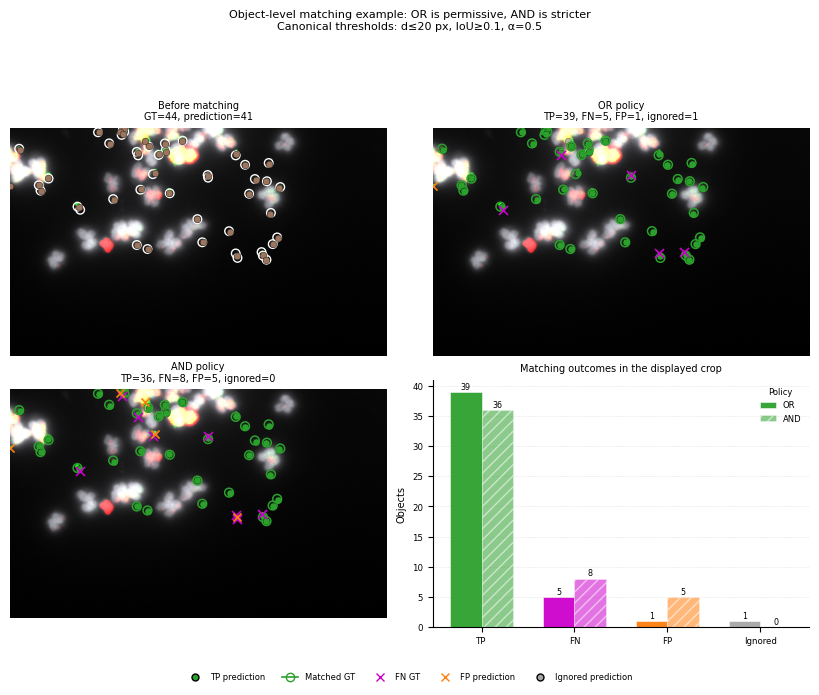

Saved: fig2_matching_example.svg
Saved: fig2_matching_example.png
Saved Fig. 2 source data:
  - /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/source_fig2_pair_table.csv
  - /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/source_fig2_matching_example_summary.csv


In [3]:
# ── Fig 2: Intuitive worked example of OR versus AND matching ───────────────
# This figure is designed for interpretability rather than debugging.
#
# It shows:
#   A. GT and prediction objects before matching
#   B. Matching outcome under the canonical OR policy
#   C. Matching outcome under the stricter AND policy
#   D. Outcome counts: TP, FN, FP, and ignored predictions
#
# Definitions:
#   TP      = assigned prediction–GT pair
#   FN      = GT object with no assigned prediction
#   FP      = prediction with no valid candidate
#   Ignored = redundant prediction that had a valid candidate but lost the
#             one-to-one assignment

from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment

D_MAX_DEMO = float(CANONICAL_D_MAX)
IOU_DEMO = float(CANONICAL_IOU_MIN)
ALPHA_DEMO = float(CANONICAL_ALPHA)
BIG_COST = 1e6


def expand_bbox_around_center(bbox, image_shape, scale=2.0):
    """Expand an x0,y0,x1,y1 bbox around its centre and clip to image bounds."""
    x0, y0, x1, y1 = bbox
    h, w = image_shape[:2]

    cx = (x0 + x1) // 2
    cy = (y0 + y1) // 2

    half_w = int((x1 - x0) * scale)
    half_h = int((y1 - y0) * scale)

    ex0 = max(0, cx - half_w)
    ex1 = min(w, cx + half_w)
    ey0 = max(0, cy - half_h)
    ey1 = min(h, cy + half_h)

    return ex0, ey0, ex1, ey1


def components_from_binary_crop(mask_crop, min_area=3):
    """Extract connected components from a binary crop."""
    mask_crop = (mask_crop > 0).astype(np.uint8)
    lab, _ = ndi.label(mask_crop, structure=np.ones((3, 3), dtype=np.uint8))
    slices = ndi.find_objects(lab)

    components = []

    for label_id, slc in enumerate(slices, start=1):
        if slc is None:
            continue

        comp_mask = lab[slc] == label_id
        area = int(comp_mask.sum())

        if area < min_area:
            continue

        y0 = int(slc[0].start)
        y1 = int(slc[0].stop)
        x0 = int(slc[1].start)
        x1 = int(slc[1].stop)

        yy, xx = np.where(comp_mask)
        cy = float(yy.mean() + y0)
        cx = float(xx.mean() + x0)

        components.append({
            'label_id': label_id,
            'area': area,
            'centroid_yx': (cy, cx),
            'bbox_xyxy': (x0, y0, x1, y1),
            'mask': comp_mask,
        })

    return lab, components


def component_iou(comp_a, comp_b):
    """Compute exact pixel IoU between two components in the same crop."""
    ax0, ay0, ax1, ay1 = comp_a['bbox_xyxy']
    bx0, by0, bx1, by1 = comp_b['bbox_xyxy']

    ix0 = max(ax0, bx0)
    iy0 = max(ay0, by0)
    ix1 = min(ax1, bx1)
    iy1 = min(ay1, by1)

    if ix1 <= ix0 or iy1 <= iy0:
        return 0.0

    a_patch = comp_a['mask'][
        iy0 - ay0:iy1 - ay0,
        ix0 - ax0:ix1 - ax0,
    ]
    b_patch = comp_b['mask'][
        iy0 - by0:iy1 - by0,
        ix0 - bx0:ix1 - bx0,
    ]

    inter = int(np.logical_and(a_patch, b_patch).sum())
    union = int(comp_a['area'] + comp_b['area'] - inter)

    return inter / union if union > 0 else 0.0


def build_pair_table(pred_components, gt_components, d_max, iou_min, alpha):
    """Build pair-level distance, IoU, cost, and OR/AND validity table."""
    rows = []

    for pred_idx, pred in enumerate(pred_components):
        py, px = pred['centroid_yx']

        for gt_idx, gt in enumerate(gt_components):
            gy, gx = gt['centroid_yx']

            distance = float(np.hypot(py - gy, px - gx))
            iou = float(component_iou(pred, gt))
            cost = alpha * (1.0 - iou) + (1.0 - alpha) * min(distance / d_max, 1.0)

            rows.append({
                'pred_idx': pred_idx,
                'gt_idx': gt_idx,
                'distance_px': distance,
                'iou': iou,
                'cost': cost,
                'valid_OR': bool((distance <= d_max) or (iou >= iou_min)),
                'valid_AND': bool((distance <= d_max) and (iou >= iou_min)),
            })

    return pd.DataFrame(rows)


def match_from_pair_table(pair_table, n_pred, n_gt, policy):
    """
    Match prediction and GT objects for one policy.

    Redundant predictions with at least one valid candidate but no final
    assignment are labelled ignored rather than FP.
    """
    valid_col = f'valid_{policy}'

    cost_matrix = np.full((n_pred, n_gt), BIG_COST, dtype=float)

    for row in pair_table.itertuples(index=False):
        if getattr(row, valid_col):
            cost_matrix[int(row.pred_idx), int(row.gt_idx)] = float(row.cost)

    matched_pairs = []
    matched_pred = set()
    matched_gt = set()

    if n_pred > 0 and n_gt > 0:
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        for pred_idx, gt_idx in zip(row_ind, col_ind):
            if cost_matrix[pred_idx, gt_idx] < BIG_COST:
                matched_pairs.append((int(pred_idx), int(gt_idx)))
                matched_pred.add(int(pred_idx))
                matched_gt.add(int(gt_idx))

    valid_pred = set(
        pair_table.loc[pair_table[valid_col], 'pred_idx']
        .astype(int)
        .unique()
        .tolist()
    )

    all_pred = set(range(n_pred))
    all_gt = set(range(n_gt))

    ignored_pred = sorted(valid_pred - matched_pred)
    fp_pred = sorted(all_pred - matched_pred - set(ignored_pred))
    fn_gt = sorted(all_gt - matched_gt)

    return {
        'policy': policy,
        'matched_pairs': matched_pairs,
        'matched_pred': matched_pred,
        'matched_gt': matched_gt,
        'ignored_pred': ignored_pred,
        'fp_pred': fp_pred,
        'fn_gt': fn_gt,
        'tp': len(matched_pairs),
        'fp': len(fp_pred),
        'fn': len(fn_gt),
        'ignored': len(ignored_pred),
    }


def draw_pre_matching_panel(ax, rgb_crop, gt_components, pred_components):
    """Draw GT and prediction centroids before assignment."""
    ax.imshow(robust_rgb_display(rgb_crop))

    for gt in gt_components:
        gy, gx = gt['centroid_yx']
        ax.scatter(
            gx, gy,
            s=38,
            facecolors='none',
            edgecolors='white',
            linewidths=1.0,
        )

    for pred in pred_components:
        py, px = pred['centroid_yx']
        ax.scatter(
            px, py,
            s=24,
            color=MODEL_COLORS['ecCount (threshold mask)'],
            edgecolors='black',
            linewidths=0.25,
        )

    ax.set_title(
        f'Before matching\nGT={len(gt_components)}, prediction={len(pred_components)}',
        fontsize=7,
    )
    ax.axis('off')


def draw_matching_panel(ax, rgb_crop, gt_components, pred_components, result):
    """Draw one policy result as intuitive overlay."""
    ax.imshow(robust_rgb_display(rgb_crop))

    # Draw matched pairs first.
    for pred_idx, gt_idx in result['matched_pairs']:
        py, px = pred_components[pred_idx]['centroid_yx']
        gy, gx = gt_components[gt_idx]['centroid_yx']

        ax.plot(
            [px, gx],
            [py, gy],
            color='#2CA02C',
            linewidth=0.8,
            alpha=0.9,
        )
        ax.scatter(
            px, py,
            s=26,
            color='#2CA02C',
            edgecolors='black',
            linewidths=0.25,
            zorder=4,
        )
        ax.scatter(
            gx, gy,
            s=40,
            facecolors='none',
            edgecolors='#2CA02C',
            linewidths=1.1,
            zorder=4,
        )

    # False negatives: GT not assigned.
    for gt_idx in result['fn_gt']:
        gy, gx = gt_components[gt_idx]['centroid_yx']
        ax.scatter(
            gx, gy,
            marker='x',
            s=42,
            color='#CC00CC',
            linewidths=1.2,
            zorder=5,
        )

    # False positives: prediction with no valid candidate.
    for pred_idx in result['fp_pred']:
        py, px = pred_components[pred_idx]['centroid_yx']
        ax.scatter(
            px, py,
            marker='x',
            s=34,
            color='#FF7F0E',
            linewidths=1.2,
            zorder=5,
        )

    # Ignored redundant predictions.
    for pred_idx in result['ignored_pred']:
        py, px = pred_components[pred_idx]['centroid_yx']
        ax.scatter(
            px, py,
            s=22,
            color='0.65',
            edgecolors='black',
            linewidths=0.2,
            alpha=0.85,
            zorder=3,
        )

    ax.set_title(
        f'{result["policy"]} policy\n'
        f'TP={result["tp"]}, FN={result["fn"]}, '
        f'FP={result["fp"]}, ignored={result["ignored"]}',
        fontsize=7,
    )
    ax.axis('off')


# Crop the full-resolution image around the locked anchor inset.
ex0, ey0, ex1, ey1 = expand_bbox_around_center(
    ANCHOR_INSET_BBOX,
    image_shape=anchor_rgb.shape,
    scale=2.0,
)

rgb_crop = anchor_rgb[ey0:ey1, ex0:ex1]
gt_crop = anchor_gt_bin[ey0:ey1, ex0:ex1]
pred_crop = thr_pred[ey0:ey1, ex0:ex1]

_, gt_local = components_from_binary_crop(
    gt_crop,
    min_area=MIN_COMPONENT_AREA,
)
_, pred_local = components_from_binary_crop(
    pred_crop,
    min_area=MIN_COMPONENT_AREA,
)

print(f'Anchor crop: x={ex0}:{ex1}, y={ey0}:{ey1}')
print(f'Objects in crop: GT={len(gt_local):,}, prediction={len(pred_local):,}')

if len(gt_local) == 0 or len(pred_local) == 0:
    print('No GT or prediction objects in the crop; matching example skipped.')

else:
    pair_table = build_pair_table(
        pred_components=pred_local,
        gt_components=gt_local,
        d_max=D_MAX_DEMO,
        iou_min=IOU_DEMO,
        alpha=ALPHA_DEMO,
    )

    or_result = match_from_pair_table(
        pair_table=pair_table,
        n_pred=len(pred_local),
        n_gt=len(gt_local),
        policy='OR',
    )

    and_result = match_from_pair_table(
        pair_table=pair_table,
        n_pred=len(pred_local),
        n_gt=len(gt_local),
        policy='AND',
    )

    # Save source data.
    pair_table.to_csv(OUT_DIR / 'source_fig2_pair_table.csv', index=False)

    outcome_df = pd.DataFrame([
        {
            'policy': 'OR',
            'tp': or_result['tp'],
            'fn': or_result['fn'],
            'fp': or_result['fp'],
            'ignored': or_result['ignored'],
            'valid_candidate_pairs': int(pair_table['valid_OR'].sum()),
        },
        {
            'policy': 'AND',
            'tp': and_result['tp'],
            'fn': and_result['fn'],
            'fp': and_result['fp'],
            'ignored': and_result['ignored'],
            'valid_candidate_pairs': int(pair_table['valid_AND'].sum()),
        },
    ])

    outcome_df.to_csv(
        OUT_DIR / 'source_fig2_matching_example_summary.csv',
        index=False,
    )

    display(outcome_df)

    # Figure: intuitive visual schematic.
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8.2, 6.6),
        gridspec_kw={'height_ratios': [1.0, 0.82]},
    )

    ax_before = axes[0, 0]
    ax_or = axes[0, 1]
    ax_and = axes[1, 0]
    ax_bar = axes[1, 1]

    draw_pre_matching_panel(
        ax_before,
        rgb_crop,
        gt_components=gt_local,
        pred_components=pred_local,
    )

    draw_matching_panel(
        ax_or,
        rgb_crop,
        gt_components=gt_local,
        pred_components=pred_local,
        result=or_result,
    )

    draw_matching_panel(
        ax_and,
        rgb_crop,
        gt_components=gt_local,
        pred_components=pred_local,
        result=and_result,
    )

    # Outcome-count bar chart.
    outcome_long = outcome_df.melt(
        id_vars='policy',
        value_vars=['tp', 'fn', 'fp', 'ignored'],
        var_name='outcome',
        value_name='count',
    )

    outcome_order = ['tp', 'fn', 'fp', 'ignored']
    outcome_labels = {
        'tp': 'TP',
        'fn': 'FN',
        'fp': 'FP',
        'ignored': 'Ignored',
    }
    outcome_colors = {
        'tp': '#2CA02C',
        'fn': '#CC00CC',
        'fp': '#FF7F0E',
        'ignored': '0.65',
    }

    x = np.arange(len(outcome_order))
    width = 0.34

    for offset, policy in [(-width / 2, 'OR'), (width / 2, 'AND')]:
        vals = [
            int(
                outcome_long[
                    (outcome_long['policy'] == policy)
                    & (outcome_long['outcome'] == outcome)
                ]['count'].iloc[0]
            )
            for outcome in outcome_order
        ]

        bars = ax_bar.bar(
            x + offset,
            vals,
            width=width,
            label=policy,
            color=[outcome_colors[o] for o in outcome_order],
            edgecolor='white',
            linewidth=0.4,
            alpha=0.95 if policy == 'OR' else 0.55,
            hatch=None if policy == 'OR' else '///',
        )

        for bar, val in zip(bars, vals):
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                str(val),
                ha='center',
                va='bottom',
                fontsize=5.8,
            )

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels([outcome_labels[o] for o in outcome_order])
    ax_bar.set_ylabel('Objects')
    ax_bar.set_title('Matching outcomes in the displayed crop', fontsize=7)
    ax_bar.grid(
        axis='y',
        linestyle='--',
        linewidth=0.4,
        alpha=0.35,
    )
    ax_bar.set_axisbelow(True)
    ax_bar.legend(
        title='Policy',
        frameon=False,
        fontsize=6,
        title_fontsize=6,
        loc='upper right',
    )

    # Unified legend for object meanings.
    legend_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor='#2CA02C',
            markeredgecolor='black',
            markersize=5,
            label='TP prediction',
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='#2CA02C',
            markerfacecolor='none',
            markersize=6,
            label='Matched GT',
        ),
        Line2D(
            [0], [0],
            marker='x',
            color='#CC00CC',
            linestyle='none',
            markersize=6,
            label='FN GT',
        ),
        Line2D(
            [0], [0],
            marker='x',
            color='#FF7F0E',
            linestyle='none',
            markersize=6,
            label='FP prediction',
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor='0.65',
            markeredgecolor='black',
            markersize=5,
            label='Ignored prediction',
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=5,
        frameon=False,
        fontsize=6,
        bbox_to_anchor=(0.5, -0.01),
    )

    fig.suptitle(
        (
            'Object-level matching example: OR is permissive, AND is stricter\n'
            f'Canonical thresholds: d≤{D_MAX_DEMO:.0f} px, '
            f'IoU≥{IOU_DEMO:g}, α={ALPHA_DEMO:g}'
        ),
        fontsize=8,
        y=1.02,
    )

    fig.tight_layout(rect=[0, 0.04, 1, 0.96])

    display(fig)
    save_fig(fig, 'fig2_matching_example')
    plt.close(fig)

    print('Saved Fig. 2 source data:')
    print(f'  - {OUT_DIR / "source_fig2_pair_table.csv"}')
    print(f'  - {OUT_DIR / "source_fig2_matching_example_summary.csv"}')

## §2 — Headline object-level F1 under OR and AND policies

The canonical benchmark uses the OR policy, which accepts a prediction–GT pair
when either centroid distance or pixel overlap supports the match. The AND
policy is stricter because both criteria must be satisfied. This section loads
the frozen policy-specific benchmark summaries and compares the resulting
headline object-level F1 for each model.

Because both summaries are read from `release/frozen_results/`, this comparison
reflects the same full benchmark pipeline used for the paper figures rather
than a notebook-time recomputation.mputation.

Models retained for OR/AND comparison (6):
  - Classic (after opt)
  - Label Engine
  - ecSeg
  - MIA
  - ecCount (threshold mask)
  - ecCount (peaks)


,model,object_f1_OR,object_f1_AND,delta_OR_minus_AND,relative_delta_percent
0,Classic (after opt),0.7771,0.4482,0.3290,73.4047
1,Label Engine,0.8246,0.5374,0.2873,53.4580
2,ecSeg,0.4637,0.2902,0.1735,59.7844
3,MIA,0.8003,0.4819,0.3184,66.0870
4,ecCount (threshold mask),0.9174,0.7652,0.1522,19.8933
5,ecCount (peaks),0.9420,0.7085,0.2334,32.9461


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/source_figS_or_vs_and_headline.csv


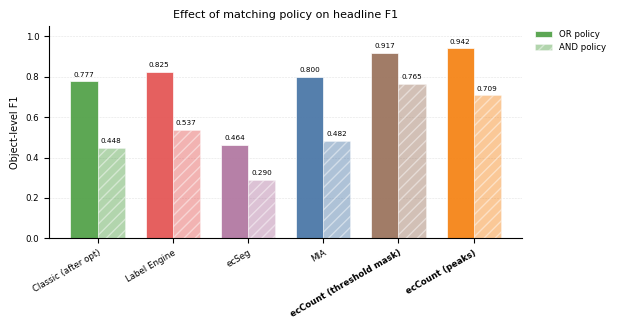

Saved: figS_or_vs_and_headline.svg
Saved: figS_or_vs_and_headline.png


In [4]:
# ── Fig S: Headline object-level F1 under OR versus AND policies ────────────
# Sources:
#   release/frozen_results/or_matching/summary_overall.csv
#   release/frozen_results/and_matching/summary_overall.csv
#
# Output:
#   figS_or_vs_and_headline.{svg,png}
#   source_figS_or_vs_and_headline.csv

OR_SUMMARY_CSV = FROZEN_OR / 'summary_overall.csv'
AND_SUMMARY_CSV = FROZEN_AND / 'summary_overall.csv'

for path in [OR_SUMMARY_CSV, AND_SUMMARY_CSV]:
    if not path.exists():
        raise FileNotFoundError(f'Frozen policy summary not found: {path}')

or_summary = pd.read_csv(OR_SUMMARY_CSV)
and_summary = pd.read_csv(AND_SUMMARY_CSV)

for label, df in [('OR', or_summary), ('AND', and_summary)]:
    if 'model' not in df.columns:
        raise KeyError(
            f'{label} summary is missing required column "model". '
            f'Available columns: {list(df.columns)}'
        )

# Standardise model labels across frozen CSV revisions.
or_summary = or_summary.copy()
and_summary = and_summary.copy()

or_summary['model'] = or_summary['model'].apply(canonical_model_name)
and_summary['model'] = and_summary['model'].apply(canonical_model_name)

or_f1_col = find_metric_column(
    or_summary,
    candidates=['obj_f1', 'object_f1', 'f1'],
    label='OR object-level F1',
)
and_f1_col = find_metric_column(
    and_summary,
    candidates=['obj_f1', 'object_f1', 'f1'],
    label='AND object-level F1',
)

models_in_or = set(or_summary['model'].dropna().astype(str))
models_in_and = set(and_summary['model'].dropna().astype(str))

models_present = [
    model_name for model_name in MODEL_ORDER
    if model_name in models_in_or and model_name in models_in_and
]

extra_models = sorted((models_in_or & models_in_and) - set(MODEL_ORDER))
models_present = models_present + extra_models

if not models_present:
    raise ValueError(
        'No overlapping models were found between OR and AND summaries after '
        'canonicalizing model names.'
    )

print(f'Models retained for OR/AND comparison ({len(models_present)}):')
for model_name in models_present:
    print(f'  - {model_name}')

or_df = (
    or_summary[or_summary['model'].isin(models_present)]
    .drop_duplicates(subset=['model'], keep='first')
    .set_index('model')
    .reindex(models_present)
)

and_df = (
    and_summary[and_summary['model'].isin(models_present)]
    .drop_duplicates(subset=['model'], keep='first')
    .set_index('model')
    .reindex(models_present)
)

compare_df = pd.DataFrame({
    'model': models_present,
    'object_f1_OR': or_df[or_f1_col].astype(float).values,
    'object_f1_AND': and_df[and_f1_col].astype(float).values,
})

compare_df['delta_OR_minus_AND'] = (
    compare_df['object_f1_OR'] - compare_df['object_f1_AND']
)

compare_df['relative_delta_percent'] = np.where(
    compare_df['object_f1_AND'] > 0,
    100.0 * compare_df['delta_OR_minus_AND'] / compare_df['object_f1_AND'],
    np.nan,
)

compare_df['model'] = pd.Categorical(
    compare_df['model'],
    categories=models_present,
    ordered=True,
)
compare_df = compare_df.sort_values('model').reset_index(drop=True)

display(compare_df.round(4))

source_csv = OUT_DIR / 'source_figS_or_vs_and_headline.csv'
compare_df.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

fig, ax = plt.subplots(figsize=(7.6, 3.3))

x = np.arange(len(compare_df))
bar_w = 0.36

or_bars = ax.bar(
    x - bar_w / 2,
    compare_df['object_f1_OR'],
    width=bar_w,
    label='OR policy',
    color=[color_for_model(m) for m in compare_df['model'].astype(str)],
    edgecolor='white',
    linewidth=0.5,
    alpha=0.95,
)

and_bars = ax.bar(
    x + bar_w / 2,
    compare_df['object_f1_AND'],
    width=bar_w,
    label='AND policy',
    color=[color_for_model(m) for m in compare_df['model'].astype(str)],
    edgecolor='white',
    linewidth=0.5,
    alpha=0.45,
    hatch='///',
)

for bars, values in [
    (or_bars, compare_df['object_f1_OR']),
    (and_bars, compare_df['object_f1_AND']),
]:
    for bar, val in zip(bars, values):
        if np.isfinite(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                min(val + 0.018, 1.02),
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=5.2,
            )

ax.set_xticks(x)
ax.set_xticklabels(
    compare_df['model'].astype(str),
    rotation=30,
    ha='right',
    rotation_mode='anchor',
)

ax.set_ylabel('Object-level F1')
ax.set_title('Effect of matching policy on headline F1')
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

for tick_label in ax.get_xticklabels():
    text = tick_label.get_text()
    if text.startswith('ecCount'):
        tick_label.set_fontweight('bold')

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=6.2,
)

fig.tight_layout(rect=[0, 0, 0.82, 1])

display(fig)
save_fig(fig, 'figS_or_vs_and_headline')
plt.close(fig)

## §3 — Sensitivity sweep over matching thresholds

The canonical benchmark uses $d_{\mathrm{max}} = 20$ px and
$\mathrm{IoU}_{\mathrm{min}} = 0.1$, but the conclusions should not depend on a
single arbitrary threshold choice. We therefore inspect the frozen sensitivity
sweep across a broad grid of distance and overlap thresholds:

- $d_{\mathrm{max}} \in \{5, 10, 15, 20, 25, 30, 40, 50, 75, 100\}$ px
- $\mathrm{IoU}_{\mathrm{min}} \in \{0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5\}$
- policy $\in$ {OR, AND}

For each model and policy, we plot pooled object-level F1 across the grid. The
white circle marks the canonical operating point used in the main benchmark.
This panel is intended to show whether each model’s performance is stable
across plausible matching settings, rather than optimized for a single
threshold pair.threshold pair.n benchmark.

Sensitivity sweep: 980 rows × 12 columns
Columns: ['model', 'split', 'policy', 'd_max', 'iou_min', 'tp', 'fp', 'fn', 'ignored', 'precision', 'recall', 'f1']


,model,split,policy,d_max,iou_min,tp,fp,fn,ignored,precision,recall,f1
0,Classic (after opt),test,and,5.0,0.00,19477,11067,14151,47,0.637670,0.579190,0.607025
1,Classic (after opt),test,and,5.0,0.05,18161,12396,15467,34,0.594332,0.540056,0.565895
2,Classic (after opt),test,and,5.0,0.10,14161,16417,19467,13,0.463111,0.421107,0.441111
3,Classic (after opt),test,and,5.0,0.20,7122,23465,26506,4,0.232844,0.211788,0.221817
4,Classic (after opt),test,and,5.0,0.30,3732,26857,29896,2,0.122005,0.110979,0.116231



Sensitivity grid retained:
  models:   7 / 7
            - Classic (before opt)
            - Classic (after opt)
            - Label Engine
            - ecSeg
            - MIA
            - ecCount (threshold mask)
            - ecCount (peaks)
  policies: ['OR', 'AND']
  d_max:    [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 75.0, 100.0]
  IoU_min:  [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
  rows:     980 retained / 980 expected for retained models
  completeness: all expected grid points are present.
Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/source_figS_sensitivity_heatmaps.csv
Saved figure: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/figS_sensitivity_heatmaps.png
Saved figure: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/figS_sensitivity_heatmaps.svg


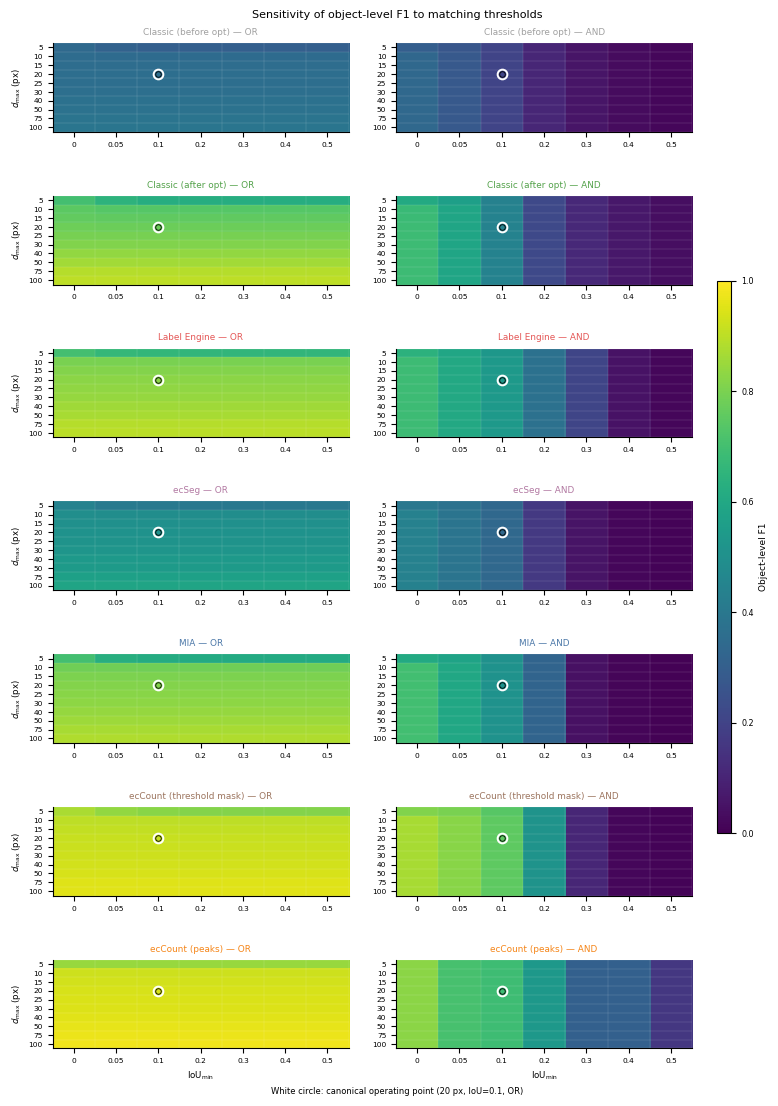

In [5]:
# ── Fig S: Sensitivity heatmaps over d_max × IoU_min ────────────────────────
# Source:
#   release/frozen_results/sensitivity/sensitivity_sweep.csv
#
# Output:
#   figS_sensitivity_heatmaps.{svg,png}
#   source_figS_sensitivity_heatmaps.csv

if not SENS_CSV.exists():
    raise FileNotFoundError(
        f'Sensitivity sweep CSV not found: {SENS_CSV}\n'
        'Run the sensitivity sweep first or point SENS_CSV to the frozen sweep file.'
    )

sens_raw = pd.read_csv(SENS_CSV)

print(f'Sensitivity sweep: {sens_raw.shape[0]:,} rows × {sens_raw.shape[1]:,} columns')
print(f'Columns: {list(sens_raw.columns)}')
display(sens_raw.head())

# Column aliases across possible sweep-script revisions.
d_col = find_metric_column(
    sens_raw,
    candidates=['d_max', 'max_dist', 'max_distance'],
    label='distance-threshold column',
)
iou_col = find_metric_column(
    sens_raw,
    candidates=['iou_min', 'min_iou', 'iou_threshold'],
    label='IoU-threshold column',
)
policy_col = find_metric_column(
    sens_raw,
    candidates=['policy', 'matching_policy'],
    label='matching-policy column',
)
sens_f1_col = find_metric_column(
    sens_raw,
    candidates=['obj_f1', 'object_f1', 'f1'],
    label='object-level F1 column',
)

if 'model' not in sens_raw.columns:
    raise KeyError(
        f'Sensitivity sweep must contain a model column. '
        f'Available columns: {list(sens_raw.columns)}'
    )

sens = sens_raw.rename(columns={
    d_col: 'd_max',
    iou_col: 'iou_min',
    policy_col: 'policy',
    sens_f1_col: 'object_f1',
}).copy()

# Standardise labels and numeric columns.
sens['model'] = sens['model'].apply(canonical_model_name)
sens['policy'] = sens['policy'].astype(str).str.upper()
sens['d_max'] = pd.to_numeric(sens['d_max'], errors='coerce')
sens['iou_min'] = pd.to_numeric(sens['iou_min'], errors='coerce')
sens['object_f1'] = pd.to_numeric(sens['object_f1'], errors='coerce')

sens = sens.dropna(
    subset=['model', 'policy', 'd_max', 'iou_min', 'object_f1']
).copy()

# Keep the canonical grid and the models represented in MODEL_ORDER.
sens = sens[
    sens['model'].isin(MODEL_ORDER)
    & sens['policy'].isin(POLICIES)
    & sens['d_max'].isin(D_MAX_GRID)
    & sens['iou_min'].isin(IOU_GRID)
].copy()

if sens.empty:
    raise ValueError(
        'No sensitivity rows remained after canonicalization/filtering. '
        'Check model names, policy labels, and grid values in SENS_CSV.'
    )

models_present = ordered_models_present(sens, model_col='model')

sens['model'] = pd.Categorical(
    sens['model'],
    categories=models_present,
    ordered=True,
)
sens['policy'] = pd.Categorical(
    sens['policy'],
    categories=POLICIES,
    ordered=True,
)

sens = sens.sort_values(['model', 'policy', 'd_max', 'iou_min']).reset_index(drop=True)

print('\nSensitivity grid retained:')
print(f'  models:   {len(models_present)} / {len(MODEL_ORDER)}')
for model_name in models_present:
    print(f'            - {model_name}')
print(f'  policies: {sens["policy"].astype(str).unique().tolist()}')
print(f'  d_max:    {sorted(sens["d_max"].unique().tolist())}')
print(f'  IoU_min:  {sorted(sens["iou_min"].unique().tolist())}')

expected_rows = (
    len(models_present)
    * len(POLICIES)
    * len(D_MAX_GRID)
    * len(IOU_GRID)
)
print(f'  rows:     {len(sens):,} retained / {expected_rows:,} expected for retained models')

# Optional completeness check. This warns but does not fail, because partial
# sweeps can still be useful during development.
observed_keys = set(
    zip(
        sens['model'].astype(str),
        sens['policy'].astype(str),
        sens['d_max'].astype(float),
        sens['iou_min'].astype(float),
    )
)

expected_keys = {
    (model_name, policy_name, float(d), float(iou))
    for model_name in models_present
    for policy_name in POLICIES
    for d in D_MAX_GRID
    for iou in IOU_GRID
}

missing_keys = expected_keys - observed_keys

if missing_keys:
    print(f'Warning: {len(missing_keys):,} expected grid points are missing.')
    print('First five missing grid points:')
    for item in sorted(missing_keys)[:5]:
        print(f'  {item}')
else:
    print('  completeness: all expected grid points are present.')

source_csv = OUT_DIR / 'source_figS_sensitivity_heatmaps.csv'
sens.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

canon_d_idx = D_MAX_GRID.index(CANONICAL_D_MAX)
canon_iou_idx = IOU_GRID.index(CANONICAL_IOU_MIN)

# -------------------------------------------------------------------------
# Figure layout
# -------------------------------------------------------------------------
# The figure is made slightly wider than before, and the subplot grid is
# restricted to the left 86% of the canvas. The colorbar is then placed in
# the reserved right-side space with fig.add_axes(...).
# -------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=len(models_present),
    ncols=len(POLICIES),
    figsize=(8.2, 1.45 * len(models_present) + 0.9),
    squeeze=False,
)

last_im = None

for row_idx, model_name in enumerate(models_present):
    for col_idx, policy_name in enumerate(POLICIES):
        ax = axes[row_idx, col_idx]

        sub = sens[
            (sens['model'].astype(str) == model_name)
            & (sens['policy'].astype(str) == policy_name)
        ].copy()

        if sub.empty:
            ax.set_visible(False)
            continue

        grid = (
            sub
            .pivot_table(
                index='d_max',
                columns='iou_min',
                values='object_f1',
                aggfunc='mean',
                observed=False,
            )
            .reindex(index=D_MAX_GRID, columns=IOU_GRID)
        )

        last_im = ax.imshow(
            grid.values,
            cmap='viridis',
            aspect='auto',
            vmin=0,
            vmax=1,
            interpolation='nearest',
        )

        # Canonical operating point.
        ax.plot(
            canon_iou_idx,
            canon_d_idx,
            marker='o',
            markersize=7,
            markerfacecolor='none',
            markeredgecolor='white',
            markeredgewidth=1.4,
            zorder=5,
        )
        ax.plot(
            canon_iou_idx,
            canon_d_idx,
            marker='o',
            markersize=4,
            markerfacecolor='none',
            markeredgecolor='black',
            markeredgewidth=0.6,
            zorder=6,
        )

        ax.set_xticks(np.arange(len(IOU_GRID)))
        ax.set_xticklabels([f'{v:g}' for v in IOU_GRID], fontsize=5.4)

        ax.set_yticks(np.arange(len(D_MAX_GRID)))
        ax.set_yticklabels([f'{int(v)}' for v in D_MAX_GRID], fontsize=5.4)

        if row_idx == len(models_present) - 1:
            ax.set_xlabel(r'IoU$_\mathrm{min}$', fontsize=6.2)
        else:
            ax.set_xlabel('')

        if col_idx == 0:
            ax.set_ylabel(r'$d_\mathrm{max}$ (px)', fontsize=6.2)
        else:
            ax.set_ylabel('')

        ax.set_title(
            f'{model_name} — {policy_name}',
            fontsize=6.4,
            color=color_for_model(model_name),
        )

        # Thin grid lines around heatmap cells.
        ax.set_xticks(np.arange(-0.5, len(IOU_GRID), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(D_MAX_GRID), 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=0.25, alpha=0.35)
        ax.tick_params(which='minor', bottom=False, left=False)

if last_im is None:
    raise RuntimeError('No heatmap panels were generated from the sensitivity sweep.')

fig.suptitle(
    'Sensitivity of object-level F1 to matching thresholds',
    fontsize=8,
    y=0.995,
)

# -------------------------------------------------------------------------
# IMPORTANT:
# Reserve right-side space for the colorbar.
# This prevents the colorbar from overlapping the right-column heatmaps.
# -------------------------------------------------------------------------

fig.subplots_adjust(
    left=0.08,
    right=0.86,
    top=0.965,
    bottom=0.055,
    hspace=0.72,
    wspace=0.16,
)

# External colorbar axis:
# [left, bottom, width, height] in figure coordinates.
cbar_ax = fig.add_axes([0.89, 0.25, 0.018, 0.50])

cbar = fig.colorbar(
    last_im,
    cax=cbar_ax,
)
cbar.set_label('Object-level F1', fontsize=6.5)
cbar.ax.tick_params(labelsize=5.8)

fig.text(
    0.5,
    0.012,
    (
        f'White circle: canonical operating point '
        f'({CANONICAL_D_MAX} px, IoU={CANONICAL_IOU_MIN:g}, OR)'
    ),
    ha='center',
    va='bottom',
    fontsize=6,
)

png_path = OUT_DIR / 'figS_sensitivity_heatmaps.png'
svg_path = OUT_DIR / 'figS_sensitivity_heatmaps.svg'

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches='tight',
)
fig.savefig(
    svg_path,
    bbox_inches='tight',
)

print(f'Saved figure: {png_path}')
print(f'Saved figure: {svg_path}')

plt.show()

## §4 — Rationale for the canonical operating point

The main benchmark uses $d_{\mathrm{max}} = 20$ px,
$\mathrm{IoU}_{\mathrm{min}} = 0.1$, and the OR matching policy. The
sensitivity sweep above provides a threshold-level justification for this
choice.

First, the OR policy is more appropriate for punctate FISH objects than a strict
AND rule. Small ecDNA foci can be correctly co-localized by centroid distance
even when pixel-level overlap is modest, especially after segmentation,
thresholding, resizing, or small registration differences. Conversely, overlap
can still support a match when centroids are slightly displaced. The OR policy
therefore treats distance and overlap as complementary evidence for the same
biological object.

Second, the canonical point lies in the central, stable region of the grid
rather than at an extreme permissive or restrictive setting. Across models, F1
is generally stable for moderate distance thresholds and low-to-moderate IoU
requirements. This supports the interpretation that the reported performance is
not cherry-picked from a narrow threshold setting.

Third, $d_{\mathrm{max}} = 20$ px provides a biologically plausible centroid
tolerance for small FISH foci while remaining restrictive enough to avoid
matching objects that are clearly spatially separated. The low IoU floor
$\mathrm{IoU}_{\mathrm{min}} = 0.1$ acts as a safeguard against gross spatial
mismatches without requiring near-perfect mask overlap for small objects.

Together, these observations support the canonical setting as a conservative
and interpretable operating point: permissive enough to handle realistic
segmentation and registration variability, but not so permissive that distant
objects are routinely matched.bjects are routinely matched.

## §5 — Robustness range across the OR-policy sweep

The heatmaps show the full threshold landscape, but a compact summary is useful
for comparing models. For each model, we summarize object-level F1 across the
entire OR-policy sensitivity sweep: 10 distance thresholds × 7 IoU thresholds =
70 grid points per model.

The horizontal line shows the minimum-to-maximum F1 range across the sweep. The
vertical tick marks the median F1, and the filled circle marks the canonical
operating point, $d_{\mathrm{max}} = 20$ px and
$\mathrm{IoU}_{\mathrm{min}} = 0.1$.

A model whose canonical point lies near the central tendency of its sweep is
less sensitive to the exact matching threshold choice. This panel therefore
summarizes whether the headline OR-policy result is representative of the
broader threshold grid rather than an isolated optimum.

,model,n_grid_points,min_f1,q25_f1,median_f1,q75_f1,max_f1,range_f1,canonical_f1,canonical_minus_median
0,Classic (before opt),70,0.3026,0.3562,0.3649,0.3777,0.3897,0.0872,0.3595,-0.0054
1,Classic (after opt),70,0.6225,0.7556,0.8027,0.8598,0.9013,0.2788,0.7748,-0.0280
2,Label Engine,70,0.6567,0.8136,0.8386,0.8693,0.8963,0.2396,0.8250,-0.0136
3,ecSeg,70,0.4001,0.5013,0.5185,0.5466,0.5829,0.1828,0.5082,-0.0103
4,MIA,70,0.6119,0.8022,0.8257,0.8546,0.8789,0.2670,0.8127,-0.0130
5,ecCount (threshold mask),70,0.8142,0.9095,0.9229,0.9397,0.9553,0.1411,0.9157,-0.0072
6,ecCount (peaks),70,0.8470,0.9331,0.9461,0.9623,0.9771,0.1301,0.9391,-0.0070


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/source_figS_sensitivity_range.csv
OR-policy grid points expected per model: 70; observed range: 70–70


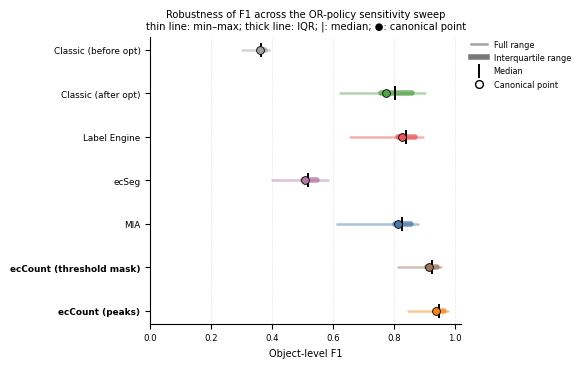

Saved: figS_sensitivity_range.svg
Saved: figS_sensitivity_range.png


In [6]:
# ── Fig S: Robustness range across the OR-policy sensitivity sweep ──────────
# Source:
#   Normalized `sens` dataframe from §3
#
# Output:
#   figS_sensitivity_range.{svg,png}
#   source_figS_sensitivity_range.csv

required_sens_cols = {'model', 'policy', 'd_max', 'iou_min', 'object_f1'}
missing_sens_cols = required_sens_cols - set(sens.columns)

if missing_sens_cols:
    raise KeyError(
        f'The normalized sensitivity dataframe is missing required columns: '
        f'{sorted(missing_sens_cols)}. Re-run §3 before this cell.'
    )

or_sens = sens[sens['policy'].astype(str) == CANONICAL_POLICY].copy()

if or_sens.empty:
    raise ValueError(
        f'No rows found for canonical policy {CANONICAL_POLICY}. '
        'Check the sensitivity dataframe from §3.'
    )

models_present = ordered_models_present(or_sens, model_col='model')

rows = []

for model_name in models_present:
    sub = or_sens[or_sens['model'].astype(str) == model_name].copy()

    canonical = sub[
        (sub['d_max'].astype(float) == float(CANONICAL_D_MAX))
        & (sub['iou_min'].astype(float) == float(CANONICAL_IOU_MIN))
    ]

    canonical_f1 = (
        float(canonical['object_f1'].iloc[0])
        if len(canonical) > 0
        else np.nan
    )

    rows.append({
        'model': model_name,
        'n_grid_points': int(len(sub)),
        'min_f1': float(sub['object_f1'].min()),
        'q25_f1': float(sub['object_f1'].quantile(0.25)),
        'median_f1': float(sub['object_f1'].median()),
        'q75_f1': float(sub['object_f1'].quantile(0.75)),
        'max_f1': float(sub['object_f1'].max()),
        'range_f1': float(sub['object_f1'].max() - sub['object_f1'].min()),
        'canonical_f1': canonical_f1,
        'canonical_minus_median': (
            canonical_f1 - float(sub['object_f1'].median())
            if np.isfinite(canonical_f1)
            else np.nan
        ),
    })

range_df = pd.DataFrame(rows)

range_df['model'] = pd.Categorical(
    range_df['model'],
    categories=models_present,
    ordered=True,
)
range_df = range_df.sort_values('model').reset_index(drop=True)

display(range_df.round(4))

source_csv = OUT_DIR / 'source_figS_sensitivity_range.csv'
range_df.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

expected_or_points = len(D_MAX_GRID) * len(IOU_GRID)
print(
    f'OR-policy grid points expected per model: {expected_or_points}; '
    f'observed range: {range_df["n_grid_points"].min()}–{range_df["n_grid_points"].max()}'
)

# ── Range plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.4, 3.7))

y = np.arange(len(range_df))

for i, row in range_df.iterrows():
    model_name = str(row['model'])
    color = color_for_model(model_name)

    if not np.isfinite(row['min_f1']) or not np.isfinite(row['max_f1']):
        continue

    # Full min-to-max range.
    ax.plot(
        [row['min_f1'], row['max_f1']],
        [i, i],
        color=color,
        linewidth=1.8,
        alpha=0.45,
        solid_capstyle='round',
    )

    # Interquartile range as a thicker central segment.
    ax.plot(
        [row['q25_f1'], row['q75_f1']],
        [i, i],
        color=color,
        linewidth=4.0,
        alpha=0.75,
        solid_capstyle='round',
    )

    # Median marker.
    ax.plot(
        row['median_f1'],
        i,
        marker='|',
        color='black',
        markersize=10,
        markeredgewidth=1.4,
        zorder=4,
    )

    # Canonical operating point.
    if np.isfinite(row['canonical_f1']):
        ax.plot(
            row['canonical_f1'],
            i,
            marker='o',
            color=color,
            markersize=5.6,
            markeredgecolor='black',
            markeredgewidth=0.6,
            zorder=5,
        )

ax.set_yticks(y)
ax.set_yticklabels(range_df['model'].astype(str), fontsize=6.4)
ax.invert_yaxis()

ax.set_xlabel('Object-level F1')
ax.set_xlim(0, 1.02)

ax.set_title(
    (
        'Robustness of F1 across the OR-policy sensitivity sweep\n'
        'thin line: min–max; thick line: IQR; |: median; ●: canonical point'
    ),
    fontsize=7.2,
)

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

for tick_label in ax.get_yticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

legend_handles = [
    Line2D(
        [0], [0],
        color='0.35',
        linewidth=1.8,
        alpha=0.55,
        label='Full range',
    ),
    Line2D(
        [0], [0],
        color='0.35',
        linewidth=4.0,
        alpha=0.8,
        label='Interquartile range',
    ),
    Line2D(
        [0], [0],
        marker='|',
        color='black',
        linestyle='none',
        markersize=10,
        markeredgewidth=1.4,
        label='Median',
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='white',
        markeredgecolor='black',
        linestyle='none',
        markersize=5.6,
        label='Canonical point',
    ),
]

ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=5.9,
)

fig.tight_layout(rect=[0, 0, 0.92, 1])

display(fig)
save_fig(fig, 'figS_sensitivity_range')
plt.close(fig)

The OR-policy robustness summary shows that the canonical operating point is
representative rather than cherry-picked. For every model, the canonical F1 is
close to the median F1 across the 70-point OR sweep, with
canonical-minus-median differences ranging from approximately -0.028 to -0.005.
The ecCount models remain the top-performing methods across the sweep:
`ecCount (peaks)` has the highest median F1 and highest canonical F1, followed
by `ecCount (threshold mask)`. The optimized classical baseline substantially
improves over the unoptimized classical pipeline, but remains below the ecCount
models. These results indicate that the main ranking is robust to reasonable
variation in the distance and IoU thresholds under the canonical OR policy.

## §6 — Robustness range under the stricter AND policy

The OR policy is used for the main benchmark because distance and overlap are
treated as complementary evidence for matching small punctate FISH objects.
Nevertheless, the stricter AND policy provides a useful stress test: a
prediction–GT pair is accepted only when both the centroid-distance and IoU
criteria are satisfied.

Here we summarize object-level F1 across the full AND-policy sensitivity sweep:
10 distance thresholds × 7 IoU thresholds = 70 grid points per model. As in the
OR-policy summary, the thin line shows the full min-to-max range, the thick line
shows the interquartile range, the vertical tick marks the median, and the
filled circle marks the same canonical threshold pair,
$d_{\mathrm{max}} = 20$ px and $\mathrm{IoU}_{\mathrm{min}} = 0.1$, now evaluated
under the AND policy.

This panel is not the primary benchmark setting. Instead, it asks whether the
relative behavior of the models remains understandable under a deliberately
stricter matching rule.

,model,n_grid_points,min_f1,q25_f1,median_f1,q75_f1,max_f1,range_f1,canonical_f1,canonical_minus_median
0,Classic (before opt),70,0.0179,0.0312,0.1055,0.2781,0.3393,0.3215,0.2047,0.0992
1,Classic (after opt),70,0.0355,0.0629,0.2218,0.5898,0.6872,0.6516,0.4431,0.2212
2,Label Engine,70,0.0180,0.0486,0.3730,0.6028,0.6874,0.6694,0.5382,0.1651
3,ecSeg,70,0.0083,0.0186,0.1660,0.3862,0.4409,0.4326,0.3376,0.1716
4,MIA,70,0.0056,0.0125,0.3217,0.5960,0.6982,0.6926,0.5109,0.1892
5,ecCount (threshold mask),70,0.0086,0.0175,0.5137,0.8205,0.8695,0.8609,0.7509,0.2372
6,ecCount (peaks),70,0.1639,0.3057,0.5325,0.7088,0.8254,0.6614,0.6906,0.1581


Saved source data: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04/source_figS_sensitivity_range_and.csv
AND-policy grid points expected per model: 70; observed range: 70–70


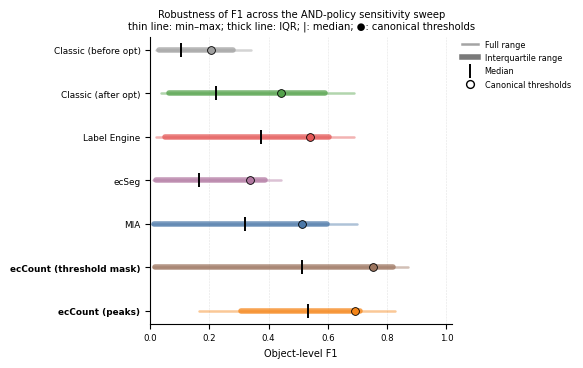

Saved: figS_sensitivity_range_and.svg
Saved: figS_sensitivity_range_and.png


In [7]:
# ── Fig S: Robustness range across the AND-policy sensitivity sweep ─────────
# Source:
#   Normalized `sens` dataframe from §3
#
# Output:
#   figS_sensitivity_range_and.{svg,png}
#   source_figS_sensitivity_range_and.csv

AND_POLICY = 'AND'

required_sens_cols = {'model', 'policy', 'd_max', 'iou_min', 'object_f1'}
missing_sens_cols = required_sens_cols - set(sens.columns)

if missing_sens_cols:
    raise KeyError(
        f'The normalized sensitivity dataframe is missing required columns: '
        f'{sorted(missing_sens_cols)}. Re-run §3 before this cell.'
    )

and_sens = sens[sens['policy'].astype(str) == AND_POLICY].copy()

if and_sens.empty:
    raise ValueError(
        f'No rows found for policy {AND_POLICY}. '
        'Check the sensitivity dataframe from §3.'
    )

models_present = ordered_models_present(and_sens, model_col='model')

rows = []

for model_name in models_present:
    sub = and_sens[and_sens['model'].astype(str) == model_name].copy()

    canonical = sub[
        (sub['d_max'].astype(float) == float(CANONICAL_D_MAX))
        & (sub['iou_min'].astype(float) == float(CANONICAL_IOU_MIN))
    ]

    canonical_f1 = (
        float(canonical['object_f1'].iloc[0])
        if len(canonical) > 0
        else np.nan
    )

    rows.append({
        'model': model_name,
        'n_grid_points': int(len(sub)),
        'min_f1': float(sub['object_f1'].min()),
        'q25_f1': float(sub['object_f1'].quantile(0.25)),
        'median_f1': float(sub['object_f1'].median()),
        'q75_f1': float(sub['object_f1'].quantile(0.75)),
        'max_f1': float(sub['object_f1'].max()),
        'range_f1': float(sub['object_f1'].max() - sub['object_f1'].min()),
        'canonical_f1': canonical_f1,
        'canonical_minus_median': (
            canonical_f1 - float(sub['object_f1'].median())
            if np.isfinite(canonical_f1)
            else np.nan
        ),
    })

and_range_df = pd.DataFrame(rows)

and_range_df['model'] = pd.Categorical(
    and_range_df['model'],
    categories=models_present,
    ordered=True,
)
and_range_df = and_range_df.sort_values('model').reset_index(drop=True)

display(and_range_df.round(4))

source_csv = OUT_DIR / 'source_figS_sensitivity_range_and.csv'
and_range_df.to_csv(source_csv, index=False)
print(f'Saved source data: {source_csv}')

expected_and_points = len(D_MAX_GRID) * len(IOU_GRID)
print(
    f'AND-policy grid points expected per model: {expected_and_points}; '
    f'observed range: '
    f'{and_range_df["n_grid_points"].min()}–{and_range_df["n_grid_points"].max()}'
)

# ── Range plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.4, 3.7))

y = np.arange(len(and_range_df))

for i, row in and_range_df.iterrows():
    model_name = str(row['model'])
    color = color_for_model(model_name)

    if not np.isfinite(row['min_f1']) or not np.isfinite(row['max_f1']):
        continue

    # Full min-to-max range.
    ax.plot(
        [row['min_f1'], row['max_f1']],
        [i, i],
        color=color,
        linewidth=1.8,
        alpha=0.45,
        solid_capstyle='round',
    )

    # Interquartile range.
    ax.plot(
        [row['q25_f1'], row['q75_f1']],
        [i, i],
        color=color,
        linewidth=4.0,
        alpha=0.75,
        solid_capstyle='round',
    )

    # Median marker.
    ax.plot(
        row['median_f1'],
        i,
        marker='|',
        color='black',
        markersize=10,
        markeredgewidth=1.4,
        zorder=4,
    )

    # Canonical threshold pair under AND policy.
    if np.isfinite(row['canonical_f1']):
        ax.plot(
            row['canonical_f1'],
            i,
            marker='o',
            color=color,
            markersize=5.6,
            markeredgecolor='black',
            markeredgewidth=0.6,
            zorder=5,
        )

ax.set_yticks(y)
ax.set_yticklabels(and_range_df['model'].astype(str), fontsize=6.4)
ax.invert_yaxis()

ax.set_xlabel('Object-level F1')
ax.set_xlim(0, 1.02)

ax.set_title(
    (
        'Robustness of F1 across the AND-policy sensitivity sweep\n'
        'thin line: min–max; thick line: IQR; |: median; ●: canonical thresholds'
    ),
    fontsize=7.2,
)

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35,
)
ax.set_axisbelow(True)

for tick_label in ax.get_yticklabels():
    if tick_label.get_text().startswith('ecCount'):
        tick_label.set_fontweight('bold')

legend_handles = [
    Line2D(
        [0], [0],
        color='0.35',
        linewidth=1.8,
        alpha=0.55,
        label='Full range',
    ),
    Line2D(
        [0], [0],
        color='0.35',
        linewidth=4.0,
        alpha=0.8,
        label='Interquartile range',
    ),
    Line2D(
        [0], [0],
        marker='|',
        color='black',
        linestyle='none',
        markersize=10,
        markeredgewidth=1.4,
        label='Median',
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='white',
        markeredgecolor='black',
        linestyle='none',
        markersize=5.6,
        label='Canonical thresholds',
    ),
]

ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    frameon=False,
    fontsize=5.9,
)

fig.tight_layout(rect=[0, 0, 0.92, 1])

display(fig)
save_fig(fig, 'figS_sensitivity_range_and')
plt.close(fig)

### Interpretation of the AND-policy stress test

The AND-policy sweep is substantially more threshold-sensitive than the
canonical OR-policy sweep. Because AND requires both centroid proximity and
minimum pixel overlap, F1 drops sharply at stricter IoU thresholds, producing
wide min-to-max ranges across the grid. This behaviour is expected for small
punctate FISH objects, where correct biological co-localization may have modest
mask overlap because of segmentation, thresholding, resizing, or small
registration differences.

The canonical threshold pair remains informative under AND, but it is no longer
near the median of the full sweep. For all models, the canonical F1 is higher
than the median AND-policy F1, indicating that AND is more dependent on the
exact threshold pair. This contrasts with the OR-policy sweep, where the
canonical point was close to the median for every model.

Despite this stricter stress test, the ecCount models remain the strongest
overall. `ecCount (peaks)` and `ecCount (threshold mask)` have the highest
canonical AND-policy F1 values and remain among the highest-performing methods
across the AND sweep. Together with the OR-policy robustness analysis, this
supports the use of OR as the primary benchmark policy: it is more stable and
better matched to the morphology of small FISH foci, while AND provides a useful
but deliberately conservative sensitivity analysis.

## §7 — Summary of saved files

In [8]:
# ── Output manifest for Notebook 04 ─────────────────────────────────────────
# This cell records every file written to release/figures/notebook04/.
# The manifest is useful for submission checks and for verifying that each
# figure has a corresponding source-data file where appropriate.

saved_files = sorted(
    [p for p in OUT_DIR.iterdir() if p.is_file()],
    key=lambda p: p.name,
)

manifest_rows = []

for path in saved_files:
    suffix = path.suffix.lower()

    if suffix in ['.svg', '.png']:
        file_type = 'figure'
    elif suffix == '.csv':
        file_type = 'source_data'
    else:
        file_type = 'other'

    manifest_rows.append({
        'filename': path.name,
        'file_type': file_type,
        'size_kb': round(path.stat().st_size / 1024, 1),
        'path': str(path),
    })

manifest_df = pd.DataFrame(manifest_rows)

display(manifest_df)

manifest_csv = OUT_DIR / 'notebook04_output_manifest.csv'
manifest_df.to_csv(manifest_csv, index=False)

print(f'Files saved to: {OUT_DIR}')
print(f'Total files: {len(manifest_df)}')
print(f'Output manifest saved: {manifest_csv.name}')

print('\nFiles:')
for row in manifest_df.itertuples(index=False):
    print(f'  {row.filename:65s}  {row.file_type:12s}  {row.size_kb:8.1f} KB')

,filename,file_type,size_kb,path
0,fig2_matching_example.png,figure,466.1,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
1,fig2_matching_example.svg,figure,2668.9,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
2,figS_or_vs_and_headline.png,figure,51.8,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
3,figS_or_vs_and_headline.svg,figure,19.5,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
4,figS_sensitivity_heatmaps.png,figure,301.9,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
5,figS_sensitivity_heatmaps.svg,figure,234.9,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
6,figS_sensitivity_range.png,figure,48.7,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
7,figS_sensitivity_range.svg,figure,22.9,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
8,figS_sensitivity_range_and.png,figure,51.8,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...
9,figS_sensitivity_range_and.svg,figure,22.9,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...


Files saved to: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook04
Total files: 17
Output manifest saved: notebook04_output_manifest.csv

Files:
  fig2_matching_example.png                                          figure           466.1 KB
  fig2_matching_example.svg                                          figure          2668.9 KB
  figS_or_vs_and_headline.png                                        figure            51.8 KB
  figS_or_vs_and_headline.svg                                        figure            19.5 KB
  figS_sensitivity_heatmaps.png                                      figure           301.9 KB
  figS_sensitivity_heatmaps.svg                                      figure           234.9 KB
  figS_sensitivity_range.png                                         figure            48.7 KB
  figS_sensitivity_range.svg                                         figure            22.9 KB
  figS_sensitivity_range_and.png                                     fi

---

## Notebook 04 complete

This notebook documented the object-level matching policy used for the benchmark
and evaluated the robustness of the model rankings to alternative matching
thresholds.

Deliverables in `release/figures/notebook04/`:

| Output | Description |
|--------|-------------|
| `fig2_matching_example.{svg,png}` | Intuitive single-image example showing OR/AND matching outcomes |
| `source_fig2_pair_table.csv` | Pair-level distance, IoU, cost, and validity table for the worked example |
| `source_fig2_matching_example_summary.csv` | TP, FN, FP, ignored, and valid-pair counts for the worked example |
| `figS_or_vs_and_headline.{svg,png}` | Headline object-level F1 under OR versus AND matching |
| `source_figS_or_vs_and_headline.csv` | Source data for the OR-versus-AND headline comparison |
| `figS_sensitivity_heatmaps.{svg,png}` | Seven-model sensitivity heatmaps across distance and IoU thresholds |
| `source_figS_sensitivity_heatmaps.csv` | Long-format source data for the sensitivity heatmaps |
| `figS_sensitivity_range.{svg,png}` | OR-policy robustness range across the 70-point threshold grid |
| `source_figS_sensitivity_range.csv` | Source data for the OR-policy robustness range |
| `figS_sensitivity_range_and.{svg,png}` | AND-policy robustness range across the 70-point threshold grid |
| `source_figS_sensitivity_range_and.csv` | Source data for the AND-policy robustness range |
| `notebook04_output_manifest.csv` | Manifest of all generated Notebook 04 outputs |

Together, the OR and AND analyses show that the canonical OR policy is stable
and appropriate for small punctate FISH objects, while the stricter AND policy
serves as a useful stress test. The seven-model sensitivity sweep confirms that
the main ecCount performance advantage is not dependent on a single arbitraoceed with documentation cleanup.